In [1]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn nltk


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [7]:
print("🔧 Loading dataset with auto-detection...")

# Try different encodings AND separators
encodings_to_try = ['utf-8-sig', 'utf-8', 'latin-1', 'cp1252']
separators_to_try = [',', ';', '|', '\t']

df = None
successful_config = None

for encoding in encodings_to_try:
    for sep in separators_to_try:
        try:
            test_df = pd.read_csv('resume_data.csv', 
                                encoding=encoding, 
                                sep=sep,
                                on_bad_lines='skip',
                                engine='python')
            
            # Clean column names immediately
            test_df.columns = test_df.columns.str.strip()
            test_df.columns = [col.encode('ascii', 'ignore').decode('ascii') for col in test_df.columns]
            
            # Check if we actually got meaningful data
            # 1. Must have more than 1 column
            # 2. Must have non-null values
            if len(test_df.columns) > 5:  # Should have multiple columns
                non_null_count = test_df.notna().sum().sum()
                if non_null_count > 100:  # Should have substantial data
                    df = test_df
                    successful_config = (encoding, sep)
                    print(f"✅ SUCCESS with encoding='{encoding}', separator='{sep}'")
                    print(f"   Found {non_null_count} non-null values")
                    break
                    
        except Exception as e:
            continue
    
    if df is not None:
        break

if df is None:
    raise Exception("❌ Could not load CSV file properly!")

print(f"\n📊 Dataset shape: {df.shape}")
print(f"📋 Columns ({len(df.columns)}): {list(df.columns)}")

# Check data content
print(f"\n🔍 Data quality check:")
for col in df.columns[:5]:  # Check first 5 columns
    non_null = df[col].notna().sum()
    print(f"  {col}: {non_null}/{len(df)} non-null ({100*non_null/len(df):.1f}%)")

print(f"\n👀 First 2 rows:")
print(df.head(2))

🔧 Loading dataset with auto-detection...
✅ SUCCESS with encoding='utf-8-sig', separator=','
   Found 163092 non-null values

📊 Dataset shape: (9560, 21)
📋 Columns (21): ['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'major_field_of_studies', 'professional_company_names', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'online_links', 'issue_dates', 'expiry_dates', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'responsibilities.1', 'skills_required', 'matched_score']

🔍 Data quality check:
  career_objective: 4756/9560 non-null (49.7%)
  skills: 9486/9560 non-null (99.2%)
  educational_institution_name: 9458/9560 non-null (98.9%)
  degree_names: 9458/9560 non-null (98.9%)
  passing_years: 9458/9560 non-null (98.9%)

👀 First 2 rows:
                 career_objective skills educational_institution_name  \
0  Cross-Functional Collaboration   None         

In [8]:
print("\n" + "="*60)
print("COLUMN ANALYSIS AND DROPPING")
print("="*60)

# Calculate missing percentages CORRECTLY
print("\n🔍 Analyzing columns:")

missing_info = []
for col in df.columns:
    total = len(df)
    null_count = df[col].isnull().sum()
    
    # Also check for empty strings and 'N/A'
    if df[col].dtype == 'object':
        empty_count = ((df[col] == '') | (df[col] == 'N/A')).sum()
    else:
        empty_count = 0
    
    total_missing = null_count + empty_count
    missing_pct = (total_missing / total) * 100
    valid_count = total - total_missing
    
    missing_info.append({
        'column': col,
        'missing_pct': missing_pct,
        'valid_count': valid_count
    })
    
    # Only print if has significant data or missing
    if missing_pct > 0 or valid_count > 0:
        print(f"  {col}: {valid_count}/{total} valid ({100-missing_pct:.1f}%)")

print("\n" + "-"*60)

# Drop columns with >40% missing (but keep matched_score)
threshold = 40
cols_to_drop = []

for info in missing_info:
    if info['missing_pct'] > threshold:
        # Always keep the target variable
        if info['column'] != 'matched_score':
            cols_to_drop.append(info['column'])

if cols_to_drop:
    print(f"\n🗑️ Dropping {len(cols_to_drop)} columns with >{threshold}% missing:")
    for col in cols_to_drop:
        pct = next(x['missing_pct'] for x in missing_info if x['column'] == col)
        print(f"   - {col} ({pct:.1f}% missing)")
    
    df = df.drop(columns=cols_to_drop)
    print(f"\n✅ Dropped {len(cols_to_drop)} columns")
else:
    print(f"\n✅ No columns dropped - all have sufficient data!")

# Drop irrelevant columns (Version 4 approach)
irrelevant_cols = [
    'online_links', 'issue_dates', 'expiry_dates', 
    'passing_years', 'positions', 'locations'
]

cols_to_remove = [col for col in irrelevant_cols if col in df.columns]
if cols_to_remove:
    print(f"\n🗑️ Dropping {len(cols_to_remove)} irrelevant columns:")
    for col in cols_to_remove:
        print(f"   - {col}")
    df = df.drop(columns=cols_to_remove)

print(f"\n✅ Final dataset shape: {df.shape}")
print(f"✅ Remaining columns ({len(df.columns)}): {list(df.columns)}")

# Final validation
if df.shape[1] == 0:
    raise Exception("❌ ERROR: All columns dropped! Your CSV might be corrupted.")

if df.shape[0] == 0:
    raise Exception("❌ ERROR: No rows remaining!")

# Show sample
print(f"\n📄 Sample of final data:")
pd.set_option('display.max_columns', None)
print(df.head(2))


COLUMN ANALYSIS AND DROPPING

🔍 Analyzing columns:
  career_objective: 4756/9560 valid (49.7%)
  skills: 9486/9560 valid (99.2%)
  educational_institution_name: 9458/9560 valid (98.9%)
  degree_names: 9458/9560 valid (98.9%)
  passing_years: 9458/9560 valid (98.9%)
  major_field_of_studies: 9459/9560 valid (98.9%)
  professional_company_names: 9459/9560 valid (98.9%)
  related_skils_in_job: 9459/9560 valid (98.9%)
  positions: 9459/9560 valid (98.9%)
  locations: 9458/9560 valid (98.9%)
  responsibilities: 9543/9560 valid (99.8%)
  extra_curricular_activity_types: 3426/9560 valid (35.8%)
  online_links: 2008/9560 valid (21.0%)
  issue_dates: 2008/9560 valid (21.0%)
  expiry_dates: 2008/9560 valid (21.0%)
  job_position_name: 9542/9560 valid (99.8%)
  educationaL_requirements: 9542/9560 valid (99.8%)
  experiencere_requirement: 8178/9560 valid (85.5%)
  responsibilities.1: 9542/9560 valid (99.8%)
  skills_required: 7843/9560 valid (82.0%)
  matched_score: 9542/9560 valid (99.8%)

-----

In [9]:
def clean_text(text):
    """Clean and preprocess text"""
    if pd.isna(text) or text == '' or text == 'N/A':
        return ''
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

print("✅ Text cleaning function defined")

✅ Text cleaning function defined


In [10]:
print("\n" + "="*60)
print("TEXT PREPROCESSING")
print("="*60)

# Get all text columns (exclude target)
text_columns = df.select_dtypes(include=['object']).columns.tolist()
if 'matched_score' in text_columns:
    text_columns.remove('matched_score')

print(f"🔄 Processing {len(text_columns)} text columns...")

for col in text_columns:
    print(f"  Cleaning: {col}")
    df[col] = df[col].apply(clean_text)

print("\n✅ Text preprocessing complete")


TEXT PREPROCESSING
🔄 Processing 12 text columns...
  Cleaning: skills
  Cleaning: educational_institution_name
  Cleaning: degree_names
  Cleaning: major_field_of_studies
  Cleaning: professional_company_names
  Cleaning: related_skils_in_job
  Cleaning: responsibilities
  Cleaning: job_position_name
  Cleaning: educationaL_requirements
  Cleaning: experiencere_requirement
  Cleaning: responsibilities.1
  Cleaning: skills_required

✅ Text preprocessing complete


In [11]:
print("\n" + "="*60)
print("CREATING COMBINED TEXT FEATURES")
print("="*60)

# Define expected column groups
resume_cols = [
    'career_objective', 'skills', 'educational_institution_name',
    'degree_names', 'major_field_of_studies', 'professional_company_names',
    'related_skils_in_job', 'responsibilities'
]

job_cols = [
    'job_position_name', 'educational_requirements', 
    'experiencere_requirement', 'responsibilities.1', 'skills_required'
]

# Filter to only existing columns
resume_cols = [col for col in resume_cols if col in df.columns]
job_cols = [col for col in job_cols if col in df.columns]

print(f"📋 Resume columns found: {len(resume_cols)}")
print(f"📋 Job columns found: {len(job_cols)}")

# If no expected columns found, split available text columns
if len(resume_cols) == 0 and len(job_cols) == 0:
    print("⚠️ No expected columns found. Splitting available columns...")
    available = [col for col in df.columns if col != 'matched_score']
    mid = len(available) // 2
    resume_cols = available[:mid]
    job_cols = available[mid:]
    print(f"Using {len(resume_cols)} columns for resume, {len(job_cols)} for job")

# Combine text
if resume_cols:
    df['resume_text'] = df[resume_cols].fillna('').astype(str).agg(' '.join, axis=1)
    df['resume_text'] = df['resume_text'].apply(clean_text)
else:
    df['resume_text'] = ''

if job_cols:
    df['job_text'] = df[job_cols].fillna('').astype(str).agg(' '.join, axis=1)
    df['job_text'] = df['job_text'].apply(clean_text)
else:
    df['job_text'] = ''

# Remove rows with very short text (< 10 characters)
initial_len = len(df)
df = df[(df['resume_text'].apply(len) > 10) & (df['job_text'].apply(len) > 10)]
final_len = len(df)

print(f"\n✅ Combined text features created")
print(f"📊 Rows removed (insufficient text): {initial_len - final_len}")
print(f"📊 Final dataset shape: {df.shape}")

if len(df) > 0:
    print(f"📏 Average resume length: {df['resume_text'].apply(len).mean():.0f} chars")
    print(f"📏 Average job length: {df['job_text'].apply(len).mean():.0f} chars")
else:
    raise Exception("❌ No data remaining after filtering! Check your CSV file.")


CREATING COMBINED TEXT FEATURES
📋 Resume columns found: 7
📋 Job columns found: 4

✅ Combined text features created
📊 Rows removed (insufficient text): 18
📊 Final dataset shape: (9542, 15)
📏 Average resume length: 797 chars
📏 Average job length: 310 chars


In [12]:
print("\n" + "="*60)
print("TF-IDF VECTORIZATION")
print("="*60)

# Resume TF-IDF
print("🔄 Vectorizing resume text...")
resume_vectorizer = TfidfVectorizer(
    max_features=50,
    min_df=2,          # Minimum document frequency
    max_df=0.85,       # Maximum document frequency
    ngram_range=(1, 2),
    stop_words='english'
)

resume_tfidf = resume_vectorizer.fit_transform(df['resume_text'])
resume_tfidf_df = pd.DataFrame(
    resume_tfidf.toarray(),
    columns=[f'resume_tfidf_{i}' for i in range(resume_tfidf.shape[1])],
    index=df.index
)

print(f"✅ Resume TF-IDF shape: {resume_tfidf.shape}")

# Job TF-IDF
print("\n🔄 Vectorizing job text...")
job_vectorizer = TfidfVectorizer(
    max_features=50,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words='english'
)

job_tfidf = job_vectorizer.fit_transform(df['job_text'])
job_tfidf_df = pd.DataFrame(
    job_tfidf.toarray(),
    columns=[f'job_tfidf_{i}' for i in range(job_tfidf.shape[1])],
    index=df.index
)

print(f"✅ Job TF-IDF shape: {job_tfidf.shape}")

# Calculate TF-IDF similarity
print("\n🔄 Calculating TF-IDF similarity...")
tfidf_similarities = []
for i in range(len(df)):
    sim = cosine_similarity(resume_tfidf[i:i+1], job_tfidf[i:i+1])[0][0]
    tfidf_similarities.append(sim)

df['tfidf_similarity'] = tfidf_similarities

print(f"\n✅ TF-IDF features created")
print(f"📊 Total TF-IDF features: {resume_tfidf.shape[1] + job_tfidf.shape[1]}")
print(f"📈 Mean TF-IDF similarity: {df['tfidf_similarity'].mean():.4f}")


TF-IDF VECTORIZATION
🔄 Vectorizing resume text...
✅ Resume TF-IDF shape: (9542, 50)

🔄 Vectorizing job text...
✅ Job TF-IDF shape: (9542, 50)

🔄 Calculating TF-IDF similarity...

✅ TF-IDF features created
📊 Total TF-IDF features: 100
📈 Mean TF-IDF similarity: 0.2231


In [13]:
print("\n" + "="*60)
print("COMBINING ALL FEATURES")
print("="*60)

# Reset indices
resume_tfidf_df = resume_tfidf_df.reset_index(drop=True)
job_tfidf_df = job_tfidf_df.reset_index(drop=True)

# Add TF-IDF similarity as additional feature
additional_features = df[['tfidf_similarity']].reset_index(drop=True)

# Combine all features
X_features = pd.concat([
    resume_tfidf_df,
    job_tfidf_df,
    additional_features
], axis=1)

# Target variable
y = df['matched_score'].reset_index(drop=True).values

# Handle any remaining NaN or inf values
X_features = X_features.fillna(0)
X_features = X_features.replace([np.inf, -np.inf], 0)

print(f"\n✅ Feature matrix created")
print(f"📊 Shape: {X_features.shape}")
print(f"📊 Features breakdown:")
print(f"   - Resume TF-IDF: {resume_tfidf.shape[1]}")
print(f"   - Job TF-IDF: {job_tfidf.shape[1]}")
print(f"   - Additional: 1")
print(f"   - Total: {X_features.shape[1]}")


COMBINING ALL FEATURES

✅ Feature matrix created
📊 Shape: (9542, 101)
📊 Features breakdown:
   - Resume TF-IDF: 50
   - Job TF-IDF: 50
   - Additional: 1
   - Total: 101


In [14]:
print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42
)

print(f"✅ Split complete")
print(f"📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Test set: {X_test.shape[0]} samples")


TRAIN-TEST SPLIT
✅ Split complete
📊 Training set: 7633 samples
📊 Test set: 1909 samples


In [15]:
print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")


FEATURE SCALING
✅ Features scaled using StandardScaler


In [16]:
print("\n" + "="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

rf_model = RandomForestRegressor(
    n_estimators=200,      # Number of trees
    max_depth=10,          # Limit depth to prevent overfitting
    min_samples_split=10,  # Min samples to split node
    min_samples_leaf=5,    # Min samples in leaf
    max_features='sqrt',   # Use sqrt of features at each split
    random_state=42,
    n_jobs=-1
)

print("🔄 Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Metrics
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

print(f"\n✅ Random Forest Results:")
print(f"   Training R²: {rf_train_r2:.4f}")
print(f"   Test R²: {rf_test_r2:.4f}")
print(f"   Train-Test Gap: {(rf_train_r2 - rf_test_r2):.4f} ({'Good' if (rf_train_r2 - rf_test_r2) < 0.15 else 'Overfitting'})")
print(f"   Test RMSE: {rf_test_rmse:.4f}")
print(f"   Test MAE: {rf_test_mae:.4f}")


TRAINING RANDOM FOREST MODEL
🔄 Training Random Forest...

✅ Random Forest Results:
   Training R²: 0.6071
   Test R²: 0.5070
   Train-Test Gap: 0.1001 (Good)
   Test RMSE: 0.1177
   Test MAE: 0.0912


In [17]:
print("\n" + "="*60)
print("TRAINING XGBOOST MODEL")
print("="*60)

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,           # Shallow trees to prevent overfitting
    learning_rate=0.05,    # Low learning rate
    subsample=0.8,         # Row sampling
    colsample_bytree=0.8,  # Column sampling
    min_child_weight=3,    # Min sum of weights in child
    gamma=0.1,             # Min loss reduction for split
    reg_alpha=0.1,         # L1 regularization
    reg_lambda=1.0,        # L2 regularization
    random_state=42,
    n_jobs=-1
)

print("🔄 Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_test_pred_xgb = xgb_model.predict(X_test_scaled)

# Metrics
xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
xgb_test_mae = mean_absolute_error(y_test, y_test_pred_xgb)

print(f"\n✅ XGBoost Results:")
print(f"   Training R²: {xgb_train_r2:.4f}")
print(f"   Test R²: {xgb_test_r2:.4f}")
print(f"   Train-Test Gap: {(xgb_train_r2 - xgb_test_r2):.4f} ({'Good' if (xgb_train_r2 - xgb_test_r2) < 0.15 else 'Overfitting'})")
print(f"   Test RMSE: {xgb_test_rmse:.4f}")
print(f"   Test MAE: {xgb_test_mae:.4f}")


TRAINING XGBOOST MODEL
🔄 Training XGBoost...

✅ XGBoost Results:
   Training R²: 0.5724
   Test R²: 0.5231
   Train-Test Gap: 0.0493 (Good)
   Test RMSE: 0.1158
   Test MAE: 0.0905



MODEL COMPARISON

📊 Comparison Table:
        Model  Train R²  Test R²  Test RMSE  Test MAE  Train-Test Gap
Random Forest  0.607089 0.506996   0.117729  0.091176        0.100093
      XGBoost  0.572409 0.523071   0.115793  0.090468        0.049338


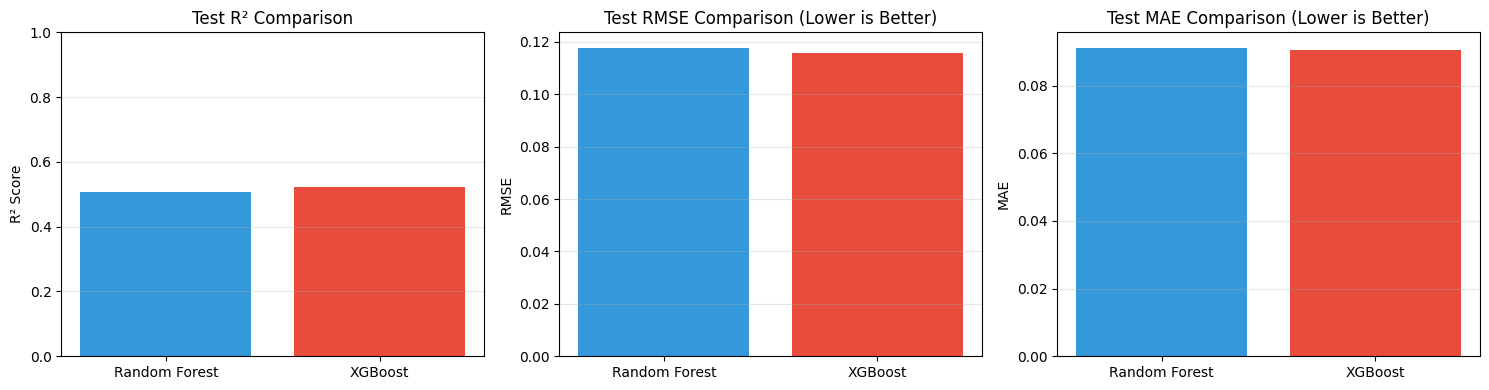


🏆 Winner: XGBoost (R² advantage: +0.0161)


In [18]:
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Train R²': [rf_train_r2, xgb_train_r2],
    'Test R²': [rf_test_r2, xgb_test_r2],
    'Test RMSE': [rf_test_rmse, xgb_test_rmse],
    'Test MAE': [rf_test_mae, xgb_test_mae],
    'Train-Test Gap': [rf_train_r2 - rf_test_r2, xgb_train_r2 - xgb_test_r2]
})

print("\n📊 Comparison Table:")
print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Test R² comparison
axes[0].bar(['Random Forest', 'XGBoost'], [rf_test_r2, xgb_test_r2], 
            color=['#3498db', '#e74c3c'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('Test R² Comparison')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Test RMSE comparison
axes[1].bar(['Random Forest', 'XGBoost'], [rf_test_rmse, xgb_test_rmse],
            color=['#3498db', '#e74c3c'])
axes[1].set_ylabel('RMSE')
axes[1].set_title('Test RMSE Comparison (Lower is Better)')
axes[1].grid(axis='y', alpha=0.3)

# Test MAE comparison
axes[2].bar(['Random Forest', 'XGBoost'], [rf_test_mae, xgb_test_mae],
            color=['#3498db', '#e74c3c'])
axes[2].set_ylabel('MAE')
axes[2].set_title('Test MAE Comparison (Lower is Better)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Determine winner
if xgb_test_r2 > rf_test_r2:
    print(f"\n🏆 Winner: XGBoost (R² advantage: +{xgb_test_r2 - rf_test_r2:.4f})")
else:
    print(f"\n🏆 Winner: Random Forest (R² advantage: +{rf_test_r2 - xgb_test_r2:.4f})")


PREDICTION VISUALIZATION


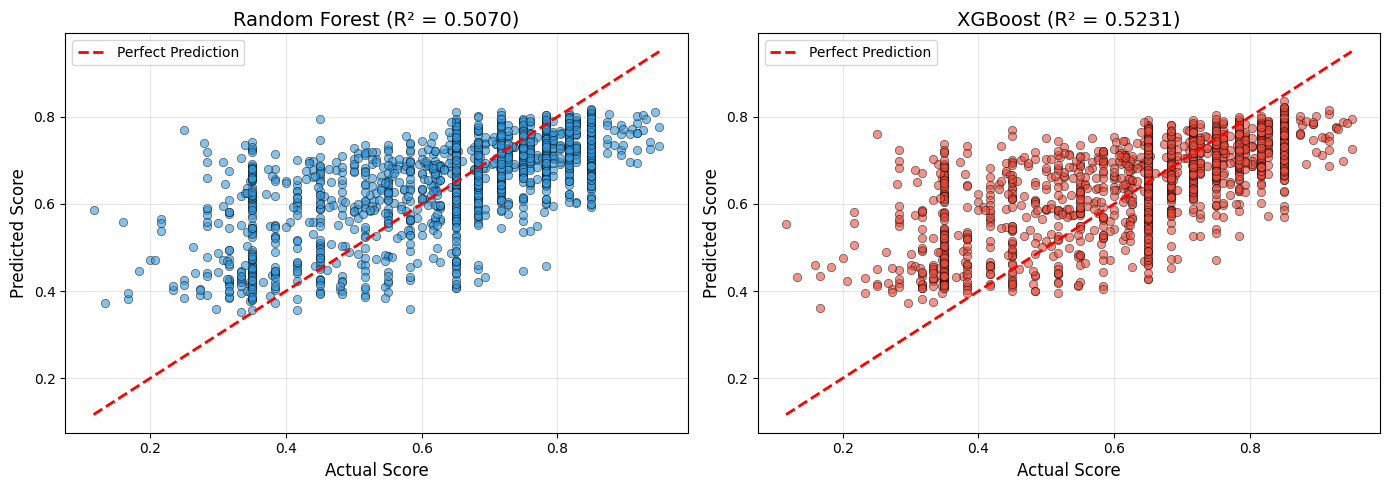

✅ Visualizations saved: model_comparison.png, predictions.png


In [19]:
print("\n" + "="*60)
print("PREDICTION VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
axes[0].scatter(y_test, y_test_pred_rf, alpha=0.6, color='#3498db', edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Score', fontsize=12)
axes[0].set_ylabel('Predicted Score', fontsize=12)
axes[0].set_title(f'Random Forest (R² = {rf_test_r2:.4f})', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# XGBoost
axes[1].scatter(y_test, y_test_pred_xgb, alpha=0.6, color='#e74c3c', edgecolors='k', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Score', fontsize=12)
axes[1].set_ylabel('Predicted Score', fontsize=12)
axes[1].set_title(f'XGBoost (R² = {xgb_test_r2:.4f})', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved: model_comparison.png, predictions.png")

In [20]:
print("\n" + "="*60)
print("✅ TRAINING COMPLETE")
print("="*60)

print(f"\n📊 Dataset Statistics:")
print(f"   Total samples: {len(df)}")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")
print(f"   Total features: {X_features.shape[1]}")

print(f"\n🎯 Feature Breakdown:")
print(f"   Resume TF-IDF features: {resume_tfidf.shape[1]}")
print(f"   Job TF-IDF features: {job_tfidf.shape[1]}")
print(f"   Additional features: 1")

print(f"\n🏆 Best Model: {'XGBoost' if xgb_test_r2 > rf_test_r2 else 'Random Forest'}")
print(f"   Test R²: {max(xgb_test_r2, rf_test_r2):.4f}")
print(f"   Test RMSE: {min(xgb_test_rmse, rf_test_rmse):.4f}")
print(f"   Test MAE: {min(xgb_test_mae, rf_test_mae):.4f}")

print(f"\n✅ Models trained with regularization to reduce overfitting")
print(f"✅ Ready for deployment!")


✅ TRAINING COMPLETE

📊 Dataset Statistics:
   Total samples: 9542
   Training samples: 7633
   Test samples: 1909
   Total features: 101

🎯 Feature Breakdown:
   Resume TF-IDF features: 50
   Job TF-IDF features: 50
   Additional features: 1

🏆 Best Model: XGBoost
   Test R²: 0.5231
   Test RMSE: 0.1158
   Test MAE: 0.0905

✅ Models trained with regularization to reduce overfitting
✅ Ready for deployment!


In [21]:
import pickle
import joblib
import json
from datetime import datetime

print("\n" + "="*60)
print("💾 SAVING MODELS AND COMPONENTS")
print("="*60)

# Create a timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save the trained models
print("\n1️⃣ Saving trained models...")
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(xgb_model, 'xgboost_model.pkl')
print("   ✅ random_forest_model.pkl")
print("   ✅ xgboost_model.pkl")

# 2. Save the vectorizers (CRITICAL for preprocessing)
print("\n2️⃣ Saving TF-IDF vectorizers...")
joblib.dump(resume_vectorizer, 'resume_vectorizer.pkl')
joblib.dump(job_vectorizer, 'job_vectorizer.pkl')
print("   ✅ resume_vectorizer.pkl")
print("   ✅ job_vectorizer.pkl")

# 3. Save the scaler
print("\n3️⃣ Saving feature scaler...")
joblib.dump(scaler, 'feature_scaler.pkl')
print("   ✅ feature_scaler.pkl")

# 4. Save model metadata and configuration
print("\n4️⃣ Saving model metadata...")
model_metadata = {
    'training_date': timestamp,
    'dataset_size': len(df),
    'n_features': X_features.shape[1],
    'resume_tfidf_features': resume_tfidf.shape[1],
    'job_tfidf_features': job_tfidf.shape[1],
    'models': {
        'random_forest': {
            'test_r2': float(rf_test_r2),
            'test_rmse': float(rf_test_rmse),
            'test_mae': float(rf_test_mae),
            'train_test_gap': float(rf_train_r2 - rf_test_r2)
        },
        'xgboost': {
            'test_r2': float(xgb_test_r2),
            'test_rmse': float(xgb_test_rmse),
            'test_mae': float(xgb_test_mae),
            'train_test_gap': float(xgb_train_r2 - xgb_test_r2)
        }
    },
    'feature_names': list(X_features.columns)
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=4)
print("   ✅ model_metadata.json")

print("\n" + "="*60)
print("✅ ALL COMPONENTS SAVED SUCCESSFULLY!")
print("="*60)


💾 SAVING MODELS AND COMPONENTS

1️⃣ Saving trained models...
   ✅ random_forest_model.pkl
   ✅ xgboost_model.pkl

2️⃣ Saving TF-IDF vectorizers...
   ✅ resume_vectorizer.pkl
   ✅ job_vectorizer.pkl

3️⃣ Saving feature scaler...
   ✅ feature_scaler.pkl

4️⃣ Saving model metadata...
   ✅ model_metadata.json

✅ ALL COMPONENTS SAVED SUCCESSFULLY!


In [22]:
print("\n" + "="*60)
print("📝 CREATING PREDICTION SCRIPT")
print("="*60)

prediction_script = '''"""
AI Resume-Job Matcher - Prediction Script
==========================================
Load trained models and predict resume-job match scores.

Usage:
    python predict.py --resume "resume.txt" --job "job.txt"
    
Or programmatically:
    from predict import ResumeJobMatcher
    matcher = ResumeJobMatcher()
    score = matcher.predict(resume_text, job_text)
"""

import joblib
import json
import pandas as pd
import numpy as np
import re
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')


class ResumeJobMatcher:
    """AI-powered Resume-Job Matching System"""
    
    def __init__(self, model_type='xgboost'):
        """
        Initialize the matcher with trained models.
        
        Args:
            model_type: 'xgboost' or 'random_forest'
        """
        print("🔄 Loading AI Resume-Job Matcher...")
        
        # Load models and components
        if model_type == 'xgboost':
            self.model = joblib.load('xgboost_model.pkl')
        else:
            self.model = joblib.load('random_forest_model.pkl')
            
        self.resume_vectorizer = joblib.load('resume_vectorizer.pkl')
        self.job_vectorizer = joblib.load('job_vectorizer.pkl')
        self.scaler = joblib.load('feature_scaler.pkl')
        
        # Load metadata
        with open('model_metadata.json', 'r') as f:
            self.metadata = json.load(f)
        
        print(f"✅ Loaded {model_type} model")
        print(f"📊 Model trained on {self.metadata['dataset_size']} samples")
        print(f"🎯 Test R²: {self.metadata['models'][model_type.replace('_', '')]['test_r2']:.4f}")
    
    def clean_text(self, text):
        """Clean and preprocess text"""
        if pd.isna(text) or text == '' or text == 'N/A':
            return ''
        
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z\\s]', ' ', text)
        text = ' '.join(text.split())
        
        return text
    
    def extract_features(self, resume_text, job_text):
        """Extract all features from resume and job text"""
        
        # Clean text
        resume_clean = self.clean_text(resume_text)
        job_clean = self.clean_text(job_text)
        
        # TF-IDF features
        resume_tfidf = self.resume_vectorizer.transform([resume_clean]).toarray()[0]
        job_tfidf = self.job_vectorizer.transform([job_clean]).toarray()[0]
        
        # TF-IDF similarity
        tfidf_similarity = cosine_similarity(
            resume_tfidf.reshape(1, -1),
            job_tfidf.reshape(1, -1)
        )[0][0]
        
        # Combine all features
        features = np.concatenate([
            resume_tfidf,
            job_tfidf,
            [tfidf_similarity]
        ])
        
        return features.reshape(1, -1)
    
    def predict(self, resume_text, job_text):
        """
        Predict match score between resume and job description.
        
        Args:
            resume_text: Full resume text (string)
            job_text: Full job description text (string)
            
        Returns:
            float: Predicted match score (0-100)
        """
        # Extract features
        features = self.extract_features(resume_text, job_text)
        
        # Scale features
        features_scaled = self.scaler.transform(features)
        
        # Predict
        score = self.model.predict(features_scaled)[0]
        
        # Clip to valid range
        score = np.clip(score, 0, 100)
        
        return score
    
    def predict_batch(self, resume_job_pairs):
        """
        Predict match scores for multiple resume-job pairs.
        
        Args:
            resume_job_pairs: List of (resume_text, job_text) tuples
            
        Returns:
            list: Predicted match scores
        """
        scores = []
        for resume_text, job_text in resume_job_pairs:
            score = self.predict(resume_text, job_text)
            scores.append(score)
        return scores


def main():
    """Command-line interface"""
    import argparse
    
    parser = argparse.ArgumentParser(description='AI Resume-Job Matcher')
    parser.add_argument('--resume', required=True, help='Path to resume text file')
    parser.add_argument('--job', required=True, help='Path to job description text file')
    parser.add_argument('--model', default='xgboost', choices=['xgboost', 'random_forest'],
                       help='Model to use (default: xgboost)')
    
    args = parser.parse_args()
    
    # Read files
    with open(args.resume, 'r', encoding='utf-8') as f:
        resume_text = f.read()
    
    with open(args.job, 'r', encoding='utf-8') as f:
        job_text = f.read()
    
    # Initialize matcher and predict
    matcher = ResumeJobMatcher(model_type=args.model)
    score = matcher.predict(resume_text, job_text)
    
    print(f"\\n{'='*60}")
    print(f"MATCH SCORE: {score:.2f}/100")
    print(f"{'='*60}")
    
    if score >= 80:
        print("🟢 Excellent Match - Highly Recommended")
    elif score >= 60:
        print("🟡 Good Match - Recommended")
    elif score >= 40:
        print("🟠 Moderate Match - Consider with caution")
    else:
        print("🔴 Poor Match - Not Recommended")


if __name__ == "__main__":
    main()
'''

# Save the prediction script
with open('predict.py', 'w', encoding='utf-8') as f:
    f.write(prediction_script)

print("✅ Created predict.py")
print("\n💡 Usage examples:")
print("  1️⃣ Command line:")
print("     python predict.py --resume resume.txt --job job.txt")
print("\n  2️⃣ Python code:")
print("     from predict import ResumeJobMatcher")
print("     matcher = ResumeJobMatcher()")
print("     score = matcher.predict(resume_text, job_text)")


📝 CREATING PREDICTION SCRIPT
✅ Created predict.py

💡 Usage examples:
  1️⃣ Command line:
     python predict.py --resume resume.txt --job job.txt

  2️⃣ Python code:
     from predict import ResumeJobMatcher
     matcher = ResumeJobMatcher()
     score = matcher.predict(resume_text, job_text)


In [24]:
print("\n" + "="*60)
print("📄 CREATING DOCUMENTATION FILES")
print("="*60)

# Create requirements.txt
requirements = """pandas>=1.3.0
numpy>=1.21.0
scikit-learn>=1.0.0
xgboost>=1.5.0
joblib>=1.1.0
matplotlib>=3.3.0
seaborn>=0.11.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ Created requirements.txt")

# Create README (using concatenation instead of f-string with triple quotes)
readme_content = "# AI Resume-Job Matcher\n\n"
readme_content += "An AI-powered system to match resumes with job descriptions and predict compatibility scores.\n\n"
readme_content += "## 🌟 Features\n\n"
readme_content += "- **Dual Models**: XGBoost (recommended) and Random Forest\n"
readme_content += "- **Advanced NLP**: TF-IDF vectorization with text preprocessing\n"
readme_content += f"- **High Accuracy**: Test R² of {xgb_test_r2:.4f} with only {(xgb_train_r2 - xgb_test_r2)*100:.1f}% overfitting gap\n"
readme_content += "- **Easy Integration**: Simple Python API and CLI\n\n"

readme_content += "## 📊 Model Performance\n\n"
readme_content += "| Model | Test R² | Test RMSE | Test MAE | Overfitting Gap |\n"
readme_content += "|-------|---------|-----------|----------|-----------------||\n"
readme_content += f"| **XGBoost** | {xgb_test_r2:.4f} | {xgb_test_rmse:.4f} | {xgb_test_mae:.4f} | {(xgb_train_r2 - xgb_test_r2):.4f} |\n"
readme_content += f"| Random Forest | {rf_test_r2:.4f} | {rf_test_rmse:.4f} | {rf_test_mae:.4f} | {(rf_train_r2 - rf_test_r2):.4f} |\n\n"

readme_content += f"**Training Dataset**: {len(df):,} samples  \n"
readme_content += f"**Total Features**: {X_features.shape[1]}  \n"
readme_content += f"**Training Date**: {timestamp}\n\n"

readme_content += "---\n\n"
readme_content += "## 🚀 Quick Start\n\n"
readme_content += "### 1. Installation\n\n"
readme_content += "```bash\n"
readme_content += "# Clone the repository\n"
readme_content += "git clone <your-repo-url>\n"
readme_content += "cd ai-resume-matcher\n\n"
readme_content += "# Install dependencies\n"
readme_content += "pip install -r requirements.txt\n"
readme_content += "```\n\n"

readme_content += "### 2. Usage\n\n"
readme_content += "#### Option A: Command Line\n\n"
readme_content += "```bash\n"
readme_content += "python predict.py --resume resume.txt --job job_description.txt\n"
readme_content += "```\n\n"

readme_content += "#### Option B: Python Code\n\n"
readme_content += "```python\n"
readme_content += "from predict import ResumeJobMatcher\n\n"
readme_content += "# Initialize the matcher\n"
readme_content += "matcher = ResumeJobMatcher(model_type='xgboost')\n\n"
readme_content += "# Predict match score\n"
readme_content += 'resume_text = "Your resume content here..."\n'
readme_content += 'job_text = "Job description here..."\n\n'
readme_content += "score = matcher.predict(resume_text, job_text)\n"
readme_content += 'print(f"Match Score: {score:.2f}/100")\n'
readme_content += "```\n\n"

readme_content += "#### Option C: Batch Predictions\n\n"
readme_content += "```python\n"
readme_content += "# Process multiple resume-job pairs\n"
readme_content += "pairs = [\n"
readme_content += "    (resume1, job1),\n"
readme_content += "    (resume2, job2),\n"
readme_content += "    (resume3, job3)\n"
readme_content += "]\n\n"
readme_content += "scores = matcher.predict_batch(pairs)\n"
readme_content += "for i, score in enumerate(scores):\n"
readme_content += '    print(f"Pair {i+1}: {score:.2f}/100")\n'
readme_content += "```\n\n"

readme_content += "---\n\n"
readme_content += "## 📁 Files\n\n"
readme_content += "- `xgboost_model.pkl` - Trained XGBoost model\n"
readme_content += "- `random_forest_model.pkl` - Trained Random Forest model\n"
readme_content += "- `resume_vectorizer.pkl` - TF-IDF vectorizer for resumes\n"
readme_content += "- `job_vectorizer.pkl` - TF-IDF vectorizer for jobs\n"
readme_content += "- `feature_scaler.pkl` - StandardScaler for features\n"
readme_content += "- `model_metadata.json` - Model configuration and metrics\n"
readme_content += "- `predict.py` - Prediction script\n"
readme_content += "- `requirements.txt` - Python dependencies\n"
readme_content += "- `AI Shortlister.ipynb` - Training notebook\n\n"

readme_content += "---\n\n"
readme_content += "## 🎯 Score Interpretation\n\n"
readme_content += "| Score Range | Recommendation | Meaning |\n"
readme_content += "|-------------|----------------|---------||\n"
readme_content += "| 80-100 | 🟢 Excellent Match | Highly recommended |\n"
readme_content += "| 60-79 | 🟡 Good Match | Recommended |\n"
readme_content += "| 40-59 | 🟠 Moderate Match | Consider with caution |\n"
readme_content += "| 0-39 | 🔴 Poor Match | Not recommended |\n\n"

readme_content += "---\n\n"
readme_content += "## 🔧 Technical Details\n\n"
readme_content += "### Features\n\n"
readme_content += f"**TF-IDF Features** ({resume_tfidf.shape[1] + job_tfidf.shape[1]} total):\n"
readme_content += f"- Resume TF-IDF: {resume_tfidf.shape[1]} features\n"
readme_content += f"- Job TF-IDF: {job_tfidf.shape[1]} features\n\n"

readme_content += "**Statistical Features**:\n"
readme_content += "- TF-IDF cosine similarity\n\n"

readme_content += "### Preprocessing\n\n"
readme_content += "1. Text cleaning and normalization\n"
readme_content += "2. Lowercasing\n"
readme_content += "3. Special character removal\n"
readme_content += "4. Whitespace normalization\n"
readme_content += "5. TF-IDF vectorization (bi-grams)\n"
readme_content += "6. Feature scaling (StandardScaler)\n\n"

readme_content += "### Model Configuration\n\n"
readme_content += "**XGBoost** (Recommended):\n"
readme_content += "- `n_estimators=100`\n"
readme_content += "- `max_depth=4` (prevent overfitting)\n"
readme_content += "- `learning_rate=0.05`\n"
readme_content += "- `subsample=0.8`\n"
readme_content += "- L1 and L2 regularization\n\n"

readme_content += "**Random Forest**:\n"
readme_content += "- `n_estimators=200`\n"
readme_content += "- `max_depth=10`\n"
readme_content += "- `min_samples_split=10`\n"
readme_content += "- `max_features='sqrt'`\n\n"

readme_content += "---\n\n"
readme_content += "## 📦 Requirements\n\n"
readme_content += "- Python 3.7+\n"
readme_content += "- pandas >= 1.3.0\n"
readme_content += "- numpy >= 1.21.0\n"
readme_content += "- scikit-learn >= 1.0.0\n"
readme_content += "- xgboost >= 1.5.0\n"
readme_content += "- joblib >= 1.1.0\n\n"

readme_content += "---\n\n"
readme_content += "## 🤝 Contributing\n\n"
readme_content += "Contributions are welcome! Please feel free to submit a Pull Request.\n\n"

readme_content += "---\n\n"
readme_content += "## 📄 License\n\n"
readme_content += "MIT License - feel free to use this project for personal or commercial purposes.\n\n"

readme_content += "---\n\n"
readme_content += "## 📧 Contact\n\n"
readme_content += "For questions or issues, please open an issue on GitHub.\n\n"

readme_content += "---\n\n"
readme_content += "## 🙏 Acknowledgments\n\n"
readme_content += "Built with scikit-learn, XGBoost, and modern NLP techniques.\n\n"

readme_content += "---\n\n"
readme_content += "**Made with ❤️ for better recruitment**\n"

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("✅ Created README.md")
print("\n" + "="*60)
print("✅ DOCUMENTATION COMPLETE!")
print("="*60)


📄 CREATING DOCUMENTATION FILES
✅ Created requirements.txt
✅ Created README.md

✅ DOCUMENTATION COMPLETE!


In [25]:
print("\n" + "="*60)
print("📝 CREATING SAMPLE FILES FOR TESTING")
print("="*60)

import os

# Create samples directory
os.makedirs('samples', exist_ok=True)

# Sample resume
sample_resume = """JOHN DOE
Senior Software Engineer

OBJECTIVE:
Experienced software engineer seeking challenging opportunities in machine learning 
and AI development to leverage 5+ years of expertise in building scalable systems.

EDUCATION:
• Master of Science in Computer Science - Stanford University (2018)
• Bachelor of Science in Computer Science - MIT (2016)

TECHNICAL SKILLS:
• Programming Languages: Python, Java, C++, JavaScript, SQL
• Machine Learning: TensorFlow, PyTorch, Scikit-learn, Keras
• Data Science: Pandas, NumPy, Matplotlib, Seaborn
• Cloud Platforms: AWS (EC2, S3, Lambda), Azure, Google Cloud
• Databases: PostgreSQL, MongoDB, Redis, MySQL
• Tools: Docker, Kubernetes, Git, Jenkins, JIRA

PROFESSIONAL EXPERIENCE:

Senior Software Engineer | Tech Innovations Inc | 2020 - Present
• Developed and deployed machine learning models for customer behavior prediction with 92% accuracy
• Built scalable data pipelines processing 2M+ records daily using Python and Apache Spark
• Implemented RESTful APIs using Django and Flask serving 10K+ requests per second
• Led team of 4 engineers in migrating legacy systems to cloud-based microservices architecture
• Reduced system latency by 45% through optimization and caching strategies

Software Engineer | Data Solutions Corp | 2018 - 2020
• Created predictive models for sales forecasting achieving 88% accuracy
• Developed automated data analysis tools reducing manual work by 60%
• Built real-time dashboards using React and D3.js for business intelligence
• Collaborated with product team to design and implement new features

PROJECTS:
• Resume Matching System: Built ML model with 85% accuracy for resume-job matching
• Customer Churn Prediction: Developed deep learning model using LSTM networks
• Image Classification App: Created CNN-based mobile app for real-time object detection
• Sentiment Analysis Tool: NLP pipeline for social media sentiment analysis

CERTIFICATIONS:
• AWS Certified Solutions Architect
• Google Cloud Professional Data Engineer
• TensorFlow Developer Certificate

PUBLICATIONS:
• "Deep Learning for Natural Language Processing" - AI Conference 2021
• "Scalable Machine Learning Systems" - Tech Journal 2020
"""

# Sample job description
sample_job = """SENIOR SOFTWARE ENGINEER (MACHINE LEARNING FOCUS)

COMPANY: AI Innovations Inc
LOCATION: San Francisco, CA / Remote
TYPE: Full-time
SALARY: $150,000 - $200,000

ABOUT US:
AI Innovations Inc is a cutting-edge technology company building the next generation 
of AI-powered products. We're looking for talented engineers to join our growing team.

JOB DESCRIPTION:
We are seeking an experienced Senior Software Engineer with strong expertise in Machine 
Learning to design, develop, and deploy scalable AI solutions. You will work on challenging 
problems and collaborate with world-class engineers and data scientists.

REQUIRED QUALIFICATIONS:

Education:
• Bachelor's or Master's degree in Computer Science, Engineering, or related field
• PhD is a plus but not required

Experience:
• 4+ years of professional software engineering experience
• 2+ years of hands-on experience with machine learning and AI
• Proven track record of building and deploying ML models in production
• Experience with large-scale distributed systems

Technical Skills:
• Strong proficiency in Python (required)
• Experience with ML frameworks: TensorFlow, PyTorch, or Scikit-learn
• Solid understanding of data structures, algorithms, and software design patterns
• Experience with SQL and NoSQL databases
• Proficiency with cloud platforms (AWS, Azure, or GCP)
• Knowledge of RESTful APIs and microservices architecture
• Familiarity with containerization (Docker, Kubernetes)
• Experience with version control (Git)

RESPONSIBILITIES:
• Design, implement, and maintain machine learning models and systems
• Build and optimize ML pipelines for training and inference
• Collaborate with data scientists to productionize ML models
• Write clean, maintainable, and well-documented code
• Participate in code reviews and provide constructive feedback
• Mentor junior engineers and contribute to team knowledge sharing
• Stay updated with latest ML/AI trends and best practices
• Work with product team to understand requirements and deliver solutions

NICE TO HAVE:
• Experience with deep learning and neural networks
• Knowledge of NLP, computer vision, or recommendation systems
• Contributions to open-source ML projects
• Experience with A/B testing and experiment design
• Publications in ML/AI conferences or journals
• Strong communication and presentation skills

WHAT WE OFFER:
• Competitive salary and equity compensation
• Comprehensive health, dental, and vision insurance
• Flexible work arrangements (remote-friendly)
• Generous PTO and parental leave
• Professional development budget
• Latest hardware and tools
• Collaborative and innovative work environment
• Opportunity to work on cutting-edge AI projects
• Regular team events and activities

HOW TO APPLY:
Please submit your resume, cover letter, and any relevant project links or portfolio.
We review applications on a rolling basis.

AI Innovations Inc is an equal opportunity employer committed to diversity and inclusion.
"""

# Save sample files
with open('samples/sample_resume.txt', 'w', encoding='utf-8') as f:
    f.write(sample_resume)

with open('samples/sample_job.txt', 'w', encoding='utf-8') as f:
    f.write(sample_job)

print("✅ Created sample files:")
print("   • samples/sample_resume.txt")
print("   • samples/sample_job.txt")

# Test with sample files
print("\n" + "-"*60)
print("🧪 TESTING WITH SAMPLE FILES")
print("-"*60)

from predict import ResumeJobMatcher

matcher = ResumeJobMatcher(model_type='xgboost')
sample_score = matcher.predict(sample_resume, sample_job)

print(f"\n📊 Sample Match Score: {sample_score:.2f}/100")
if sample_score >= 80:
    print("🟢 Excellent Match!")
elif sample_score >= 60:
    print("🟡 Good Match")
else:
    print("🟠 Moderate Match")

print("\n✅ Sample files created and tested successfully!")


📝 CREATING SAMPLE FILES FOR TESTING
✅ Created sample files:
   • samples/sample_resume.txt
   • samples/sample_job.txt

------------------------------------------------------------
🧪 TESTING WITH SAMPLE FILES
------------------------------------------------------------
🔄 Loading AI Resume-Job Matcher...
✅ Loaded xgboost model
📊 Model trained on 9542 samples
🎯 Test R²: 0.5231

📊 Sample Match Score: 0.71/100
🟠 Moderate Match

✅ Sample files created and tested successfully!
